In [1]:
import pandas as pd
from doubleml.datasets import fetch_401K
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

In [2]:
from utils import print_metrics

In [3]:
def load_401k_dataset() -> tuple[pd.DataFrame, list[str]]:
    # Fetch as a native DoubleMLData container to extract mapped column names
    dml_data = fetch_401K(return_type="DoubleMLData")
    
    # Extract underlying DataFrame and map to target pipeline names
    df = dml_data.data.copy()
    df = df.rename(
        columns={
            dml_data.d_cols[0]: "treatment",  # "e401" -> eligibility for the 401(k) plan
            dml_data.y_col: "outcome",  # "net_tfa" -> net financial assets (in USD)
        }
    )
    
    feature_columns = dml_data.x_cols

    # Drop unused variables
    keep_variables = feature_columns + ["treatment", "outcome"]
    df = df[keep_variables]
    
    return df, feature_columns

In [4]:
df, feature_columns = load_401k_dataset()

In [5]:
# Deal with extreme skewness

# Uniform percentile rank [0, 1]
df["outcome_rank"] = df["outcome"].rank(pct=True)

# Normal quantiles (maps ranks to a clean Bell Curve N(0,1))
df["outcome_norm_quantile"] = norm.ppf(df["outcome"].rank(pct=True).clip(0.001, 0.999))

In [6]:
df.head()

,age,inc,educ,fsize,marr,twoearn,db,pira,hown,treatment,outcome,outcome_rank,outcome_norm_quantile
0,47,6765.0,8,2,0,0,0,0,1,0,0.0,0.332224,-0.433781
1,36,28452.0,16,1,0,0,0,0,1,0,1015.0,0.480585,-0.048685
2,37,3300.0,12,6,0,0,1,0,0,0,-2000.0,0.175593,-0.932293
3,58,52590.0,16,2,1,1,0,0,1,0,15000.0,0.737670,0.636179
4,32,21804.0,11,1,0,0,0,0,1,0,0.0,0.332224,-0.433781


In [7]:
df.describe().round(2)

,age,inc,educ,fsize,marr,twoearn,db,pira,hown,treatment,outcome,outcome_rank,outcome_norm_quantile
count,9915.00,9915.00,9915.00,9915.00,9915.00,9915.00,9915.00,9915.00,9915.00,9915.00,9915.00,9915.00,9915.00
mean,41.06,37200.62,13.21,2.87,0.60,0.38,0.27,0.24,0.64,0.37,18051.53,0.50,0.00
std,10.34,24774.29,2.81,1.54,0.49,0.49,0.44,0.43,0.48,0.48,63522.50,0.29,1.00
min,25.00,-2652.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,-502302.00,0.00,-3.09
25%,32.00,19413.00,12.00,2.00,0.00,0.00,0.00,0.00,0.00,0.00,-500.00,0.25,-0.67
50%,40.00,31476.00,12.00,3.00,1.00,0.00,0.00,0.00,1.00,0.00,1499.00,0.50,0.00
75%,48.00,48583.50,16.00,4.00,1.00,1.00,1.00,0.00,1.00,1.00,16524.50,0.75,0.67
max,64.00,242124.00,18.00,13.00,1.00,1.00,1.00,1.00,1.00,1.00,1536798.00,1.00,3.09


In [8]:
ratio_treated = df["treatment"].mean()
print(f"Eligible population: {ratio_treated:.2%}")

Eligible population: 37.14%


In [9]:
mean_treated = df.loc[df["treatment"] == 1, "outcome"].mean()
mean_untreated = df.loc[df["treatment"] == 0, "outcome"].mean()
naive_gap = mean_treated - mean_untreated
print(f"Mean treated: {mean_treated:.2f}")
print(f"Mean untreated: {mean_untreated:.2f}")
print(f"Naive gap (difference between the average net financial assets of treated vs. non treated subjects): USD {naive_gap:.2f}")

Mean treated: 30347.39
Mean untreated: 10788.05
Naive gap (difference between the average net financial assets of treated vs. non treated subjects): USD 19559.34


In [10]:
variables = {
    "age": "Age (years)",
    "inc": "Annual income (USD)",
    "educ": "Education (years)",
    "fsize": "Family size",
    "marr": "Married status (1=Yes, 0=No)",
    "twoearn": "Two-earner household (1=Yes, 0=No)",
    "db": "Defined benefit pension plan (1=Yes, 0=No)",
    "pira": "IRA participation (1=Yes, 0=No)",
    "hown": "Homeowner status (1=Yes, 0=No)",
    "treatment": "401(k) plan eligibility (1=Eligible, 0=Not eligible)",
    "outcome": "Net total financial assets (USD)",
    "outcome_norm_quantile": "Compressed net total financial assets (USD)",
}

In [11]:
def plot_variable_by_401k_eligibility(
    df: pd.DataFrame,
    variable_name: str,
    variable_description: str,
    coverage: float = 0.99,
) -> None:
    
    sns.set_theme(style="whitegrid", font="sans-serif")
    
    df_plot = df.copy()
    treatment_map = {0: "Not Eligible", 1: "Eligible"}
    df_plot["treatment_label"] = df_plot["treatment"].map(treatment_map)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={"wspace": 0.25}, layout="constrained")
    
    colors = {"Not Eligible": "#E66101", "Eligible": "#5E3C99"}

    # Distribution (KDE + histogram)
    for val, label in treatment_map.items():
        subset = df_plot[df_plot["treatment"] == val][variable_name].dropna()

        # Histogram bars
        axes[0].hist(
            subset,
            bins=40,
            density=True,
            alpha=0.35,
            color=colors[label],
            label=f"{label} (e401={val})",
            edgecolor="white",
            linewidth=0.8,
        )

        # Smooth kernel density estimate overlay
        sns.kdeplot(
            subset,
            ax=axes[0],
            color=colors[label],
            linewidth=2,
            warn_singular=False,
        )

    axes[0].set_xlabel(variable_description.capitalize(), fontsize=11)
    axes[0].set_ylabel("Density", fontsize=11)
    axes[0].set_title(
        f"Distribution of {variable_description}\nby 401(k) Eligibility",
        fontsize=12,
        pad=10,
    )
    axes[0].legend(frameon=True, facecolor="white", framealpha=0.9)

    # Boxplot
    sns.boxplot(
        data=df_plot,
        x="treatment_label",
        y=variable_name,
        hue="treatment_label",
        legend=False,
        ax=axes[1],
        palette=colors,
        width=0.4,
        fliersize=2,
        flierprops={"alpha": 0.3, "markerfacecolor": "gray"},
        boxprops={"alpha": 0.85},
    )

    axes[1].set_xlabel("401(k) Eligibility", fontsize=11)
    axes[1].set_ylabel(variable_description.capitalize(), fontsize=11)
    axes[1].set_title(
        f"{variable_description.capitalize()} Summary Statistics",
        fontsize=12,
        pad=10,
    )

    # Dynamic quantile clipping (coverage)
    lower_p = (1.0 - coverage) / 2.0
    upper_p = 1.0 - lower_p

    q_low = df_plot[variable_name].quantile(lower_p)
    q_high = df_plot[variable_name].quantile(upper_p)

    #axes[0].set_xlim(q_low, q_high)
    #axes[1].set_ylim(q_low, q_high)
    
    # Final polish
    for ax in axes:
        sns.despine(ax=ax)
        ax.tick_params(labelsize=10)

    plt.show()

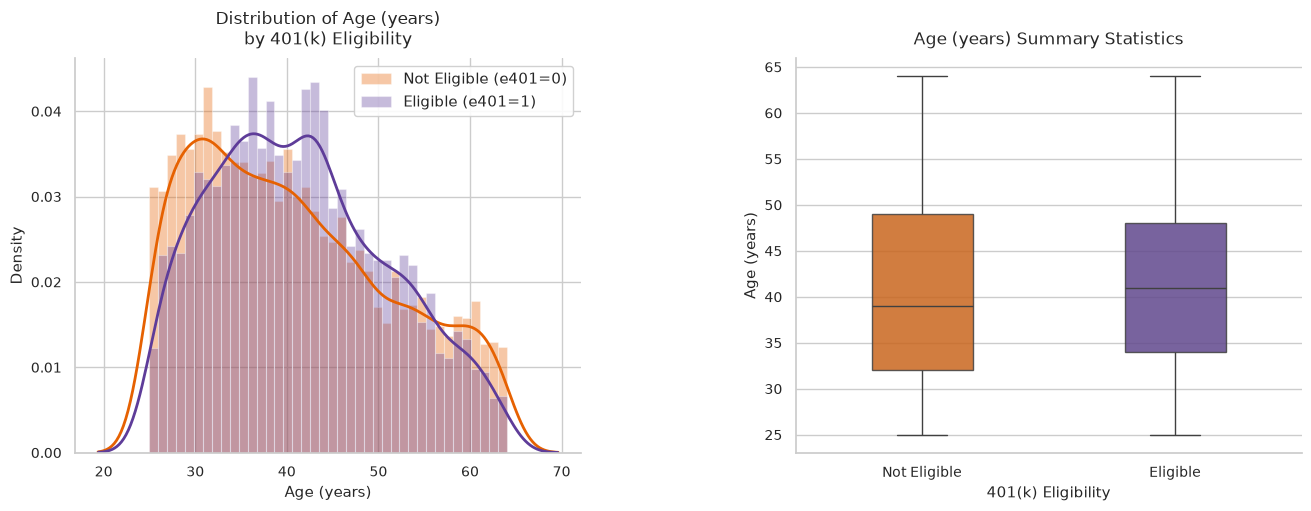

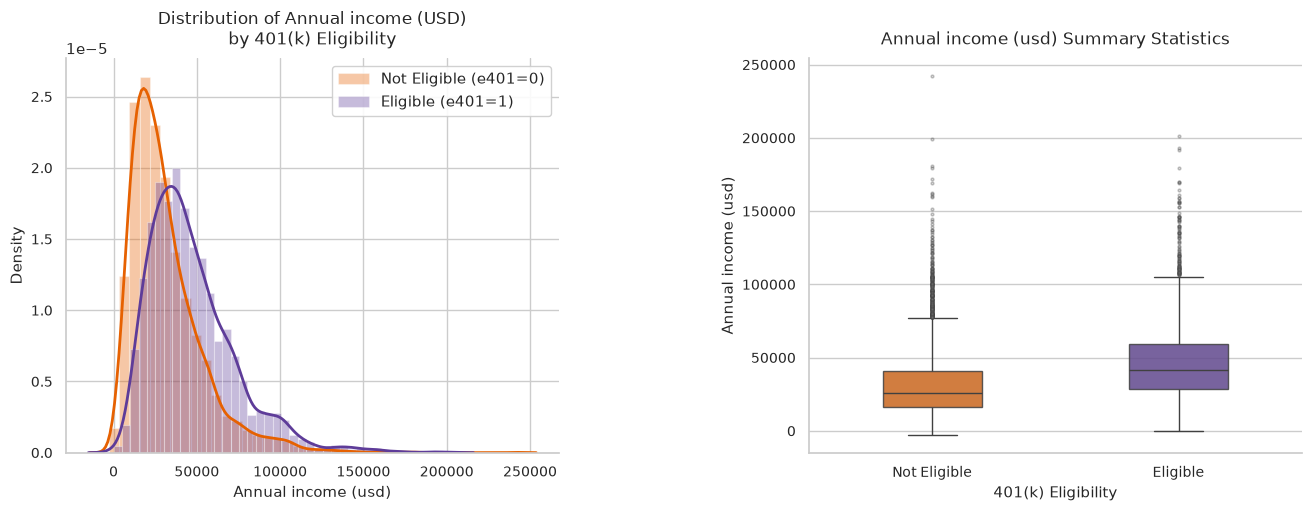

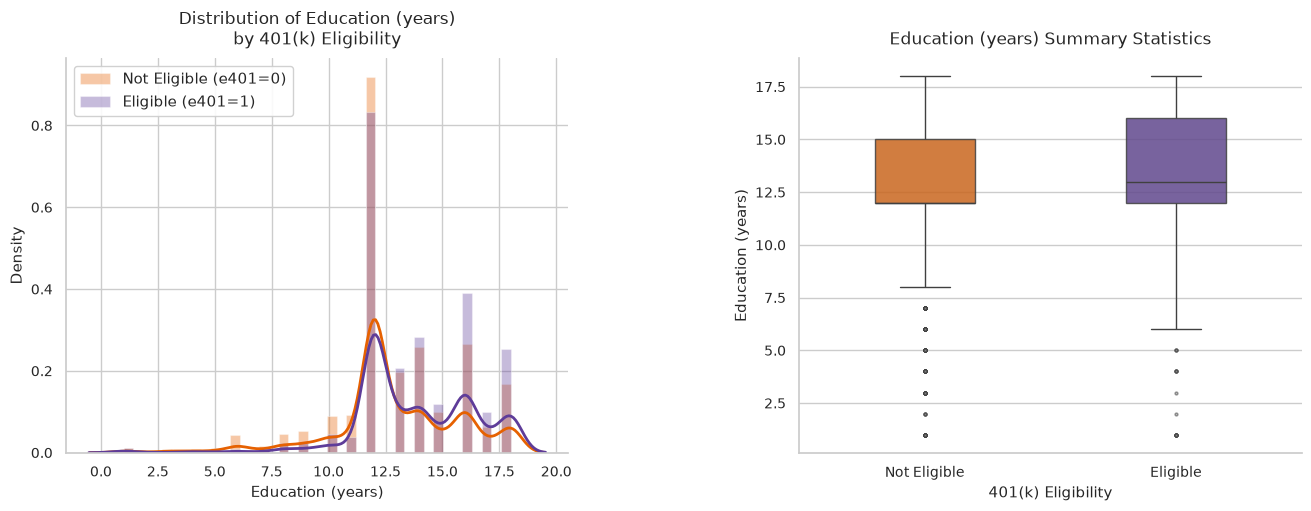

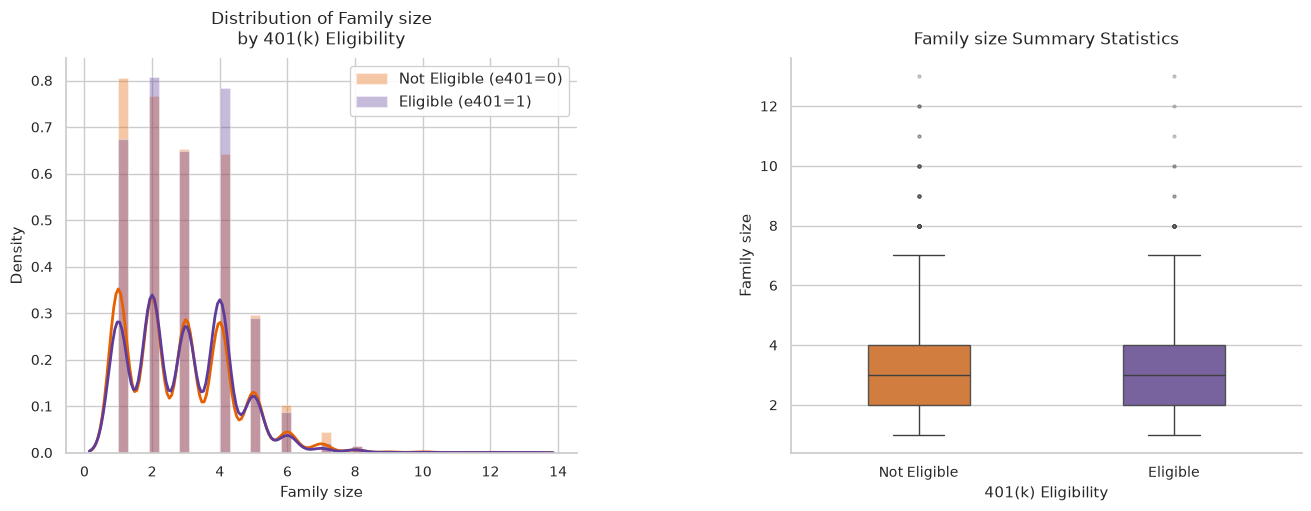

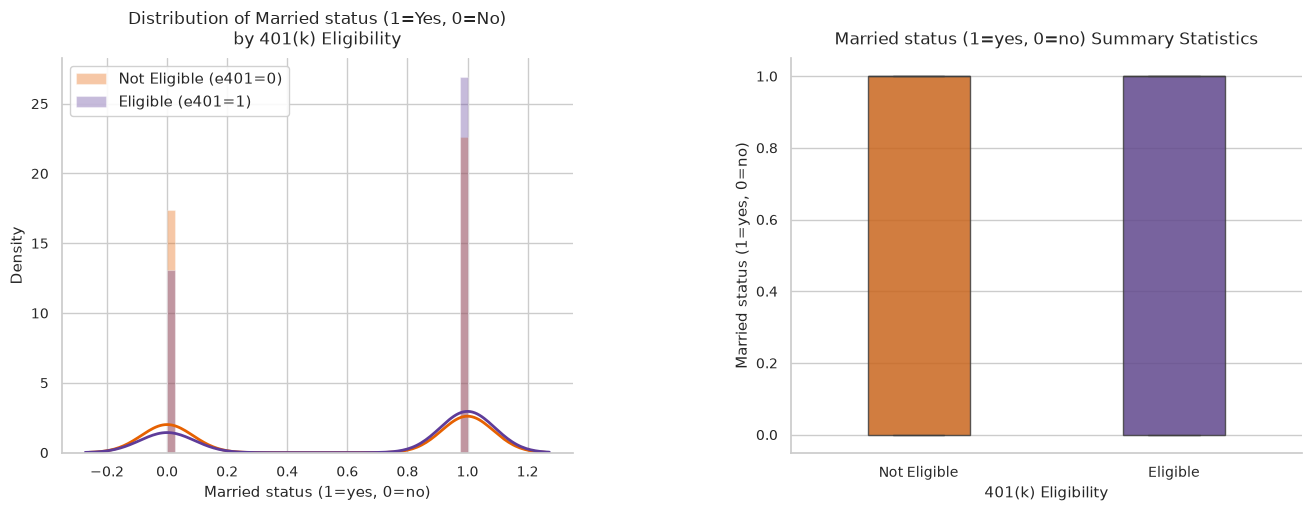

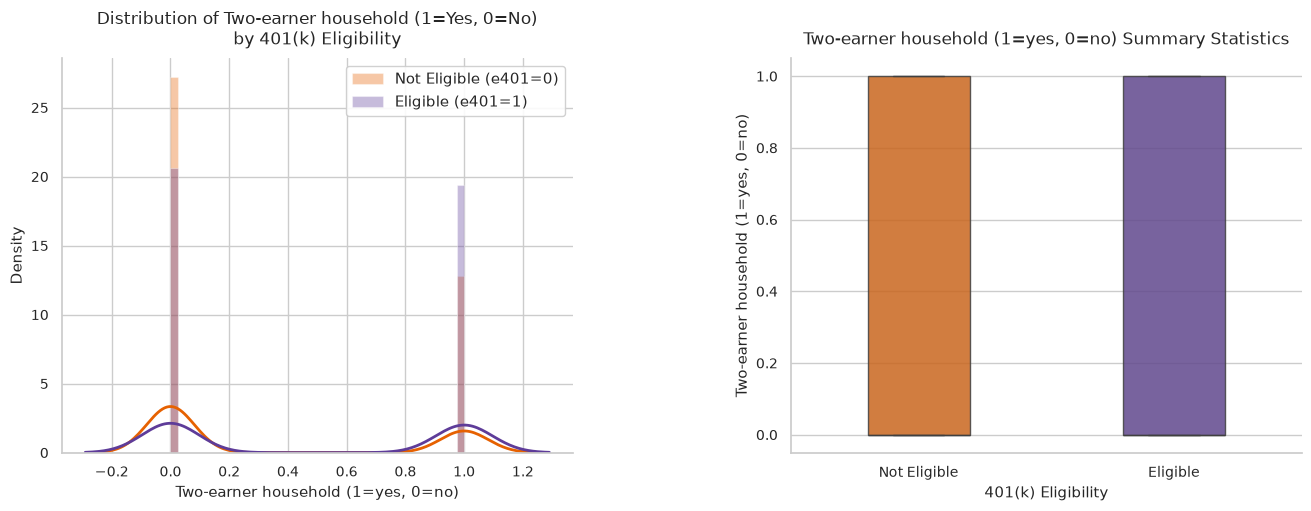

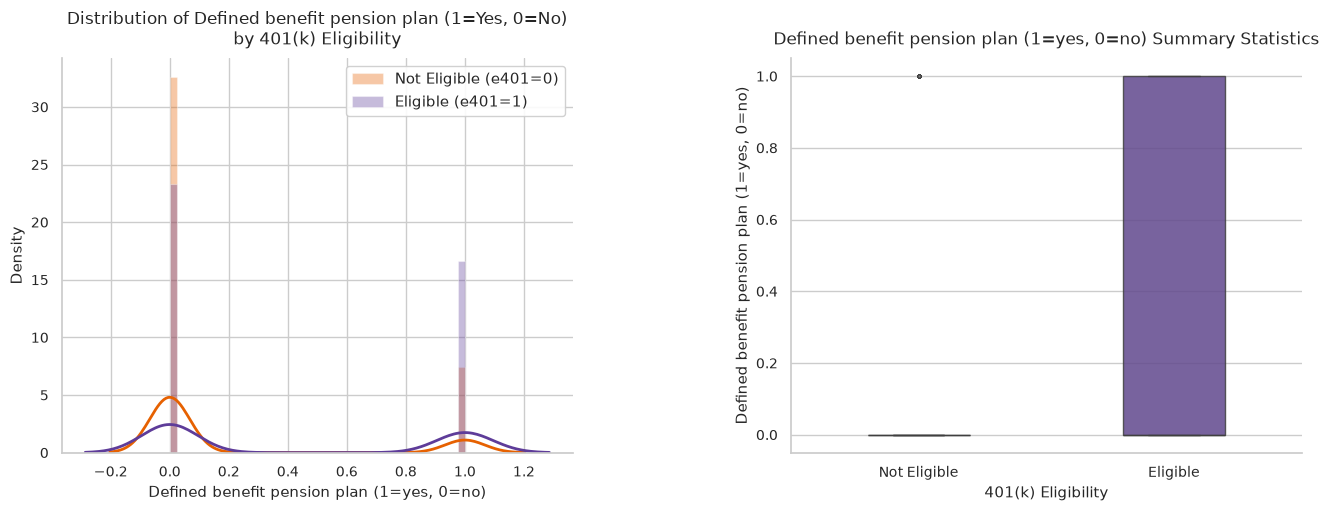

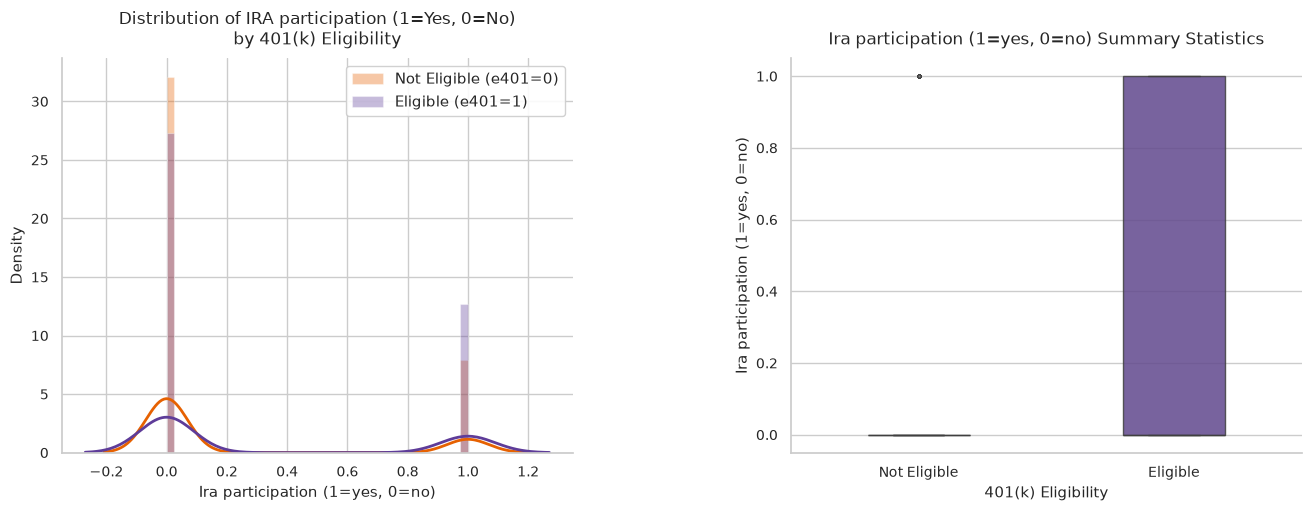

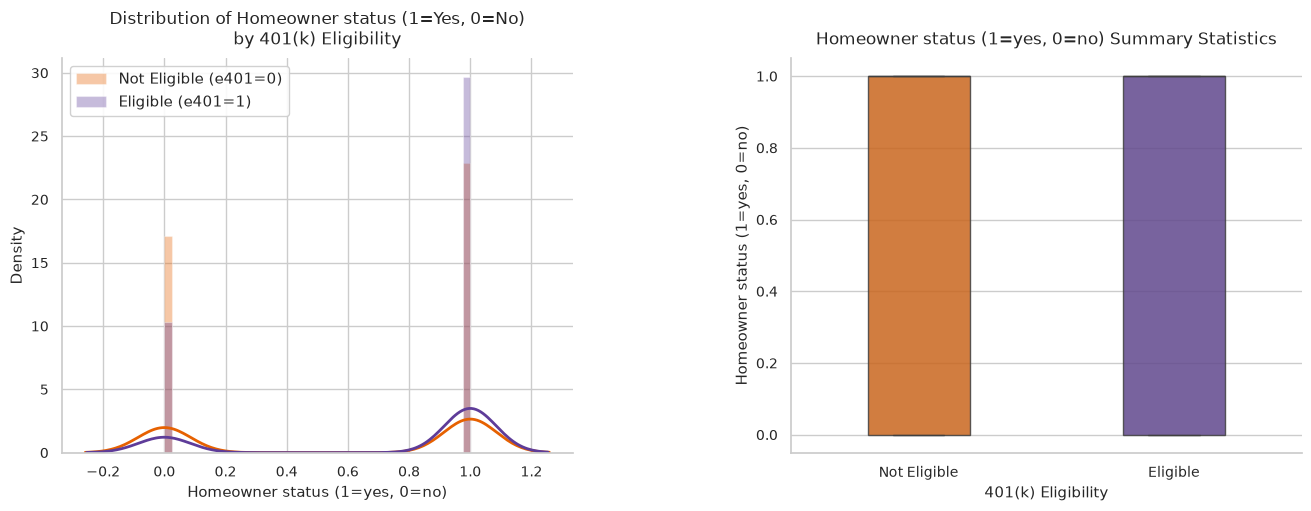

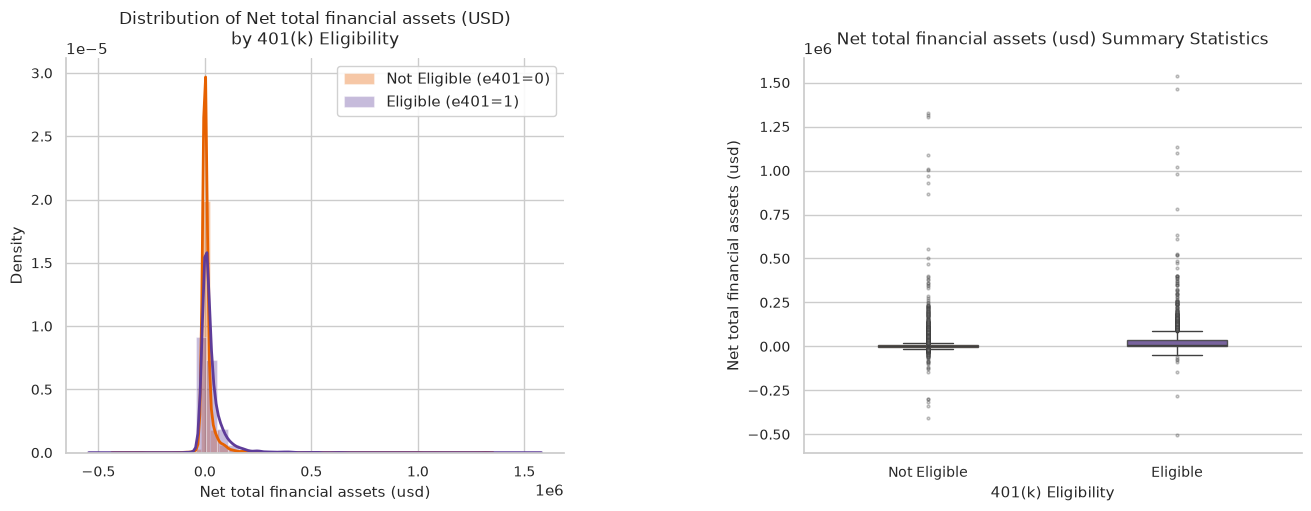

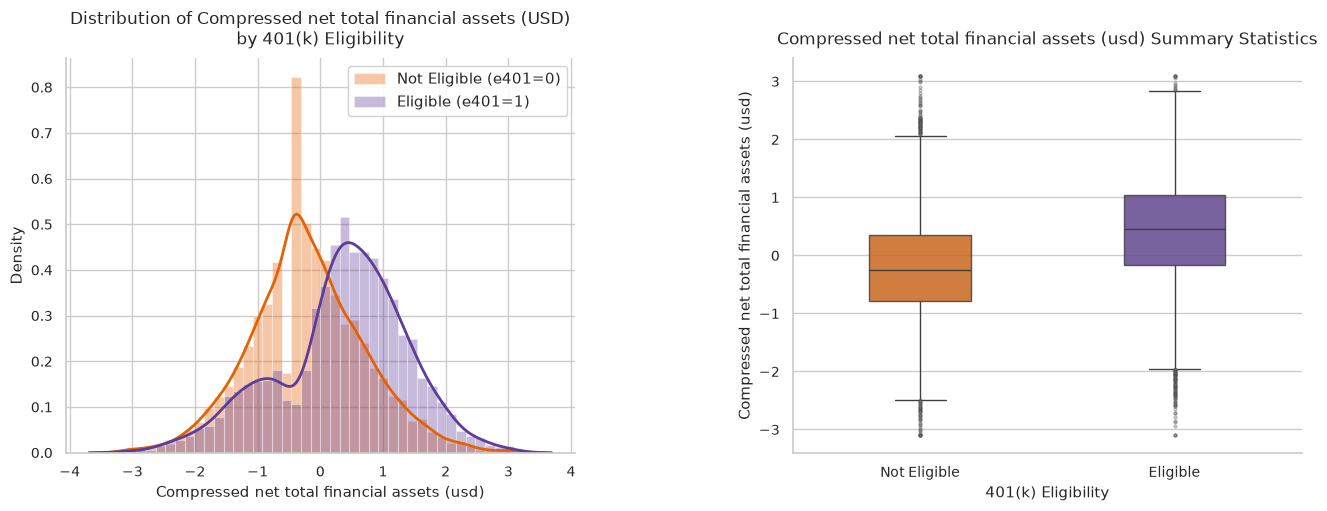

In [12]:
for variable_name, variable_description in variables.items():
    if variable_name in ["treatment"]:
        continue
    plot_variable_by_401k_eligibility(
        df=df,
        variable_name=variable_name,
        variable_description=variable_description,
    )

In [13]:
from econml.dml import CausalForestDML, LinearDML
from xgboost import XGBClassifier, XGBRegressor
from causal_parameters import CausalParameters
import numpy as np
from sklearn.model_selection import KFold


def double_ml_econml_inline(
    df: pd.DataFrame,
    feature_columns: list[str],
    treatment_column: str = "treatment",        
    outcome_column: str = "outcome",    
    ) -> CausalParameters:
    
    X = df[feature_columns]
    W = df[treatment_column]
    Y = df[outcome_column]

    cv_splitter = KFold(n_splits=10, shuffle=True, random_state=0)
    
    # Define base machine learning model for outcome nuisance: m(X) = E[Y | X]
    model_y = XGBRegressor(
        n_estimators=1000,
        max_depth=2,
        learning_rate=0.05,
        random_state=0
        )

    # Define base machine learning model for propensity nuisance: e(X) = P(W=1 | X)
    model_t = XGBClassifier(
        n_estimators=1000,
        max_depth=2,
        learning_rate=0.05,
        random_state=0,
        eval_metric="logloss",
        )

    # Initialize the double machine learning estimator
    model = LinearDML(
        model_y=model_y,
        model_t=model_t,
        discrete_treatment=True,
        cv=cv_splitter,
        random_state=0,
        )

    # Fit the double ML model on observational data [X, W, Y] (EconML expects Y and W as 1D arrays or column vectors)
    model.fit(Y=Y.to_numpy(), T=W.to_numpy(), X=X)

    # Confidence intervals for the quantities \tau(X, T0, T1) produced by the model (one pair per subject)
    cate_lower, cate_upper = model.effect_interval(X, alpha=0.05)

    # Confidence interval for the quantity E[\tau(X, T0, T1)] produced by the model (one pair in total)
    ate = float(model.ate(X))
    ate_lower, ate_upper = model.ate_interval(X)

    # Predict counterfactual treatment effects (CATE) across sample X
    cate_raw = model.effect(X)

    # Flatten output array to 1D float64 array for evaluation
    cate = np.asarray(cate_raw, dtype=np.float64).ravel()

    causal_parameters = CausalParameters(
        cate=cate,
        cate_lower=cate_lower,
        cate_upper=cate_upper,
        ate=ate,
        ate_lower=ate_lower,
        ate_upper=ate_upper
        )


    # Check
    propensity_scores = model.models_t[0][0].predict_proba(df[feature_columns])[:, 1]
    sns.kdeplot(propensity_scores[df["treatment"] == 1], label="Eligible")
    sns.kdeplot(propensity_scores[df["treatment"] == 0], label="Not Eligible")    
    
    return causal_parameters

double_ml_econml
Predicted ATE: 0.31, 95% CI: [0.27, 0.34], Width: 0.07
CATE Distribution — Mean: 0.31, Std: 0.14
CATE Quartiles — 25th: 0.21, Median: 0.31, 75th: 0.41
Mean CATE 95% CI: [0.19, 0.42], Average width: 0.23



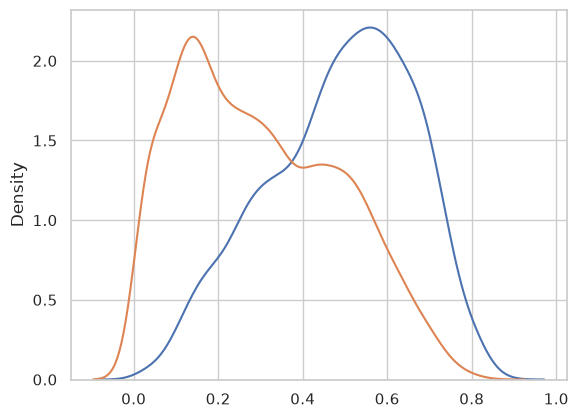

In [14]:
causal_parameters = double_ml_econml_inline(
    df=df,
    feature_columns=feature_columns,
    treatment_column="treatment",
    outcome_column="outcome_norm_quantile"
    )

print_metrics("double_ml_econml", causal_parameters, true_cate=None)

In [15]:
def interpret_ate_in_usd(
    df: pd.DataFrame,
    ate_z: float,
    ci_lower_z: float,
    ci_upper_z: float,
    raw_outcome_col: str = "outcome",
) -> dict:
    # Baseline benchmark: median household (Z = 0.0)
    base_z = 0.0
    base_pct = norm.cdf(base_z)
    base_dollars = np.percentile(df[raw_outcome_col], base_pct * 100)

    # Treated estimates on Z-scale mapped to percentiles
    treated_z = base_z + ate_z
    treated_low_z = base_z + ci_lower_z
    treated_high_z = base_z + ci_upper_z

    # Percentiles in [0, 100]
    pct_point = norm.cdf(treated_z) * 100
    pct_low = norm.cdf(treated_low_z) * 100
    pct_high = norm.cdf(treated_high_z) * 100

    # Map percentiles back to empirical dollar distribution
    dollars_point = np.percentile(df[raw_outcome_col], pct_point)
    dollars_low = np.percentile(df[raw_outcome_col], pct_low)
    dollars_high = np.percentile(df[raw_outcome_col], pct_high)

    return {
        "baseline_median_usd": base_dollars,
        "ate_usd_lift": dollars_point - base_dollars,
        "ci_lower_usd_lift": dollars_low - base_dollars,
        "ci_upper_usd_lift": dollars_high - base_dollars,
    }

In [16]:
dollar_interpretation = interpret_ate_in_usd(
    df=df,
    ate_z=causal_parameters.ate,
    ci_lower_z=causal_parameters.ate_lower,
    ci_upper_z=causal_parameters.ate_upper
    )

print(f"Baseline Median: ${dollar_interpretation['baseline_median_usd']:,.2f}")
print(
    f"Estimated Dollar ATE Lift: ${dollar_interpretation['ate_usd_lift']:,.2f} "
    f"(95% CI: [${dollar_interpretation['ci_lower_usd_lift']:,.2f}, ${dollar_interpretation['ci_upper_usd_lift']:,.2f}])"
)

Baseline Median: $1,499.00
Estimated Dollar ATE Lift: $4,100.09 (95% CI: [$3,500.00, $4,751.00])


## Validation

double_ml_econml (with placebo)
Predicted ATE: 0.02, 95% CI: [-0.02, 0.05], Width: 0.06
CATE Distribution — Mean: 0.02, Std: 0.05
CATE Quartiles — 25th: -0.01, Median: 0.01, 75th: 0.04
Mean CATE 95% CI: [-0.09, 0.12], Average width: 0.20



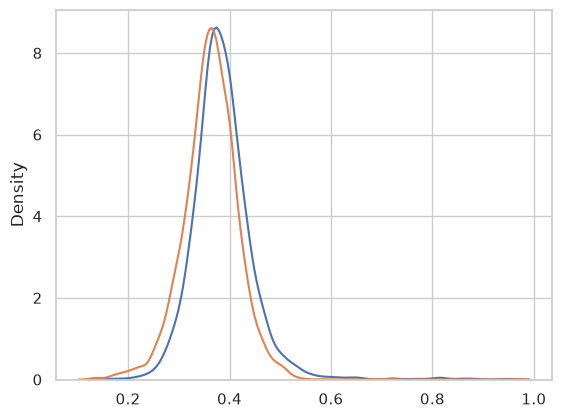

In [17]:
# Create a permuted (placebo) treatment column
df_placebo = df.copy()
df_placebo["treatment"] = np.random.permutation(df_placebo["treatment"].values)

# Re-fit Double ML on the fake treatment
placebo_results = double_ml_econml_inline(
    df=df_placebo,
    feature_columns=feature_columns,
    outcome_column="outcome_norm_quantile",
)

# Verify whether the placebo ATE drops near to zero
print_metrics("double_ml_econml (with placebo)", placebo_results, true_cate=None)